In [20]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines import NelsonAalenFitter

pd.set_option("display.max_columns", 100)

In [21]:
df = pd.read_csv("../../data/train.csv")

### Censoring

**Note**: 0 is censored, 1 is not censored. This is right censoring

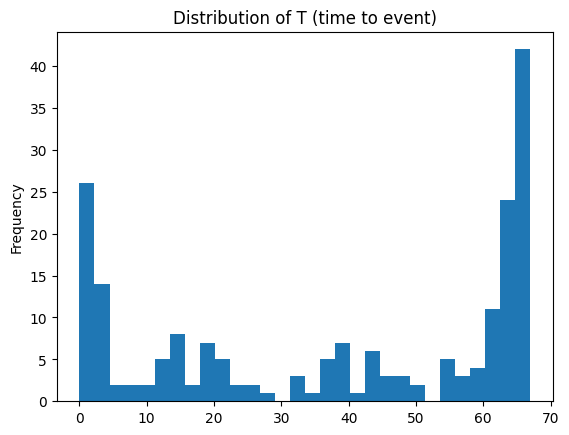

In [22]:
ax = df['time_to_hit_hours'].plot(kind="hist", bins = 30)

ax.set_title("Distribution of T (time to event)")

plt.show()


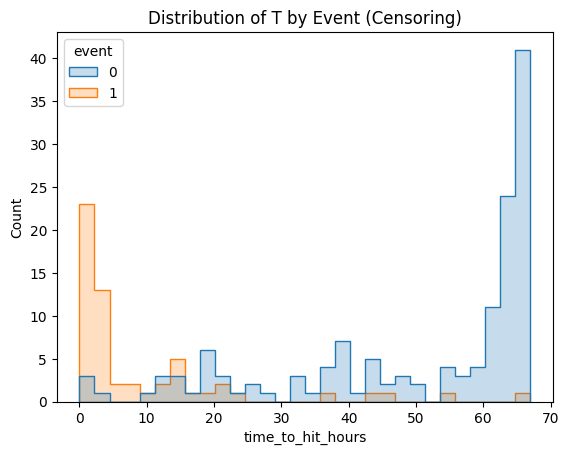

In [23]:
sns.histplot(data=df, x = "time_to_hit_hours", hue="event", bins = 30, element="step")

plt.title("Distribution of T by Event (Censoring)")
plt.show()

In [24]:
censored = df['event'] == 0

print(censored.mean())

0.7070707070707071


### Kaplan-Meier Curve - $\hat{S}(t)$

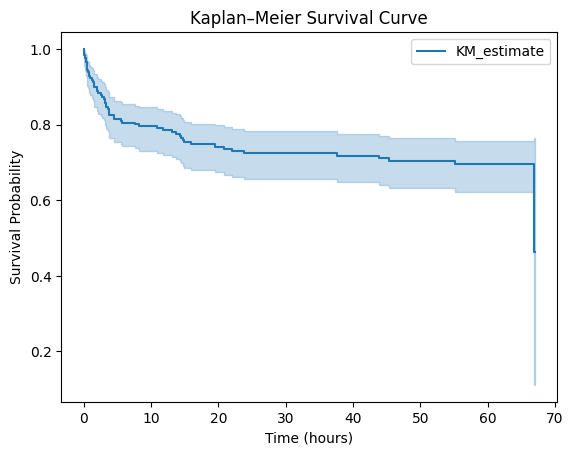

In [25]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=df["time_to_hit_hours"], 
    event_observed=df["event"]
)

kmf.plot()

plt.title("Kaplan–Meier Survival Curve")
plt.xlabel("Time (hours)")
plt.ylabel("Survival Probability")
plt.show()

### Hazard Curve - $h(t)$

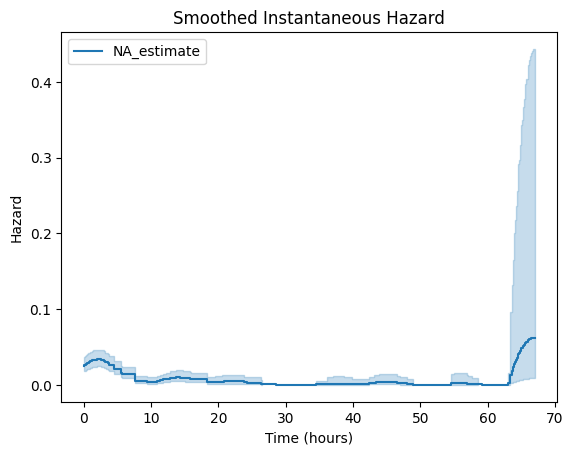

In [26]:
naf = NelsonAalenFitter()

naf.fit(
    durations=df["time_to_hit_hours"],
    event_observed=df["event"]
)

naf.plot_hazard(bandwidth=4)

plt.title("Smoothed Instantaneous Hazard")
plt.xlabel("Time (hours)")
plt.ylabel("Hazard")
plt.show()

### Base Rates at Horizons

In [27]:
print(kmf.survival_function_.head())

          KM_estimate
timeline             
0.000000     1.000000
0.001220     0.994949
0.007176     0.989899
0.064361     0.984848
0.130320     0.979798


In [28]:
print("Base survival probability for t=12:",kmf.predict(12))
print("Base survival probability for t=24:",kmf.predict(24))
print("Base survival probability for t=48:",kmf.predict(48))
print("Base survival probability for t=72:",kmf.predict(72))


Base survival probability for t=12: 0.7846854087283937
Base survival probability for t=24: 0.7242097470607941
Base survival probability for t=48: 0.7031644219613571
Base survival probability for t=72: 0.4633880481890933


In [29]:
print("Base hit probability for t=12:",1 - kmf.predict(12))
print("Base hit probability for t=24:",1 - kmf.predict(24))
print("Base hit probability for t=48:",1 - kmf.predict(48))
print("Base hit probability for t=72:",1 - kmf.predict(72))

Base hit probability for t=12: 0.21531459127160635
Base hit probability for t=24: 0.2757902529392059
Base hit probability for t=48: 0.2968355780386429
Base hit probability for t=72: 0.5366119518109067
